## Indicators of Heart Disease

------------------
Data: [Indicators of Heart Disease](https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease?resource=download)

Models: 

- Logistic regression
- Decision tree
- Decision forest

----------------

In [1]:
import pickle

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import auc, roc_curve, roc_auc_score, f1_score, precision_recall_curve, classification_report
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.__version__

'2.2.2'

### Loading the data

In [2]:
df = pd.read_csv("../data/heart_2020_cleaned.csv")
print(df.shape)
df.head()

(319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


### Exploratory Data Analysis

#### Exploring types

In [3]:
df.dtypes

HeartDisease         object
BMI                 float64
Smoking              object
AlcoholDrinking      object
Stroke               object
PhysicalHealth      float64
MentalHealth        float64
DiffWalking          object
Sex                  object
AgeCategory          object
Race                 object
Diabetic             object
PhysicalActivity     object
GenHealth            object
SleepTime           float64
Asthma               object
KidneyDisease        object
SkinCancer           object
dtype: object

Some types are float64

Others are object, so they will be encoded with one-hot encoding

#### Checking for NA

In [4]:
sum(df.isna().sum())

0

There is no missed values in the data

#### Looking at the target variable

In [5]:
heartdisease_vc = df['HeartDisease'].value_counts()
heartdisease_vc

HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64

Ratio: 0.09


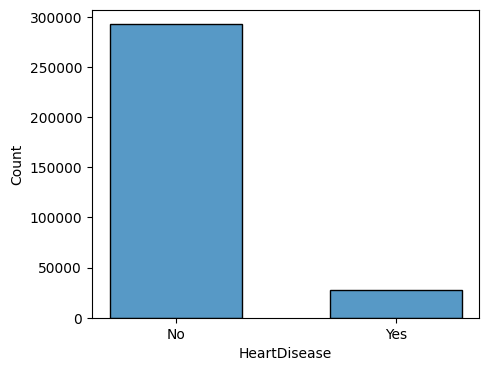

In [6]:
print(f'Ratio: {round(heartdisease_vc.iloc[1]/sum(heartdisease_vc),2)}')
plt.subplots(figsize=(5, 4))
sns.histplot(df['HeartDisease'], shrink=0.6)
plt.show()

Target classes are unbalanced, so we will use F1 score as an evaluation metric

#### Looking at the number of unique values

In [7]:
for c in df.columns:
    print(c, len(df[c].value_counts()))

HeartDisease 2
BMI 3604
Smoking 2
AlcoholDrinking 2
Stroke 2
PhysicalHealth 31
MentalHealth 31
DiffWalking 2
Sex 2
AgeCategory 13
Race 6
Diabetic 4
PhysicalActivity 2
GenHealth 5
SleepTime 24
Asthma 2
KidneyDisease 2
SkinCancer 2


Most of the variables have only two different values. Let's look at those which have more than two unique values

In [8]:
more_than_two = ['BMI', 'PhysicalHealth', 'MentalHealth', 'AgeCategory', 'Race', 'Diabetic', 'GenHealth', 'SleepTime']
df_mtw = df[more_than_two]
df_mtw.head(3)

,BMI,PhysicalHealth,MentalHealth,AgeCategory,Race,Diabetic,GenHealth,SleepTime
0,16.60,3.0,30.0,55-59,White,Yes,Very good,5.0
1,20.34,0.0,0.0,80 or older,White,No,Very good,7.0
2,26.58,20.0,30.0,65-69,White,Yes,Fair,8.0


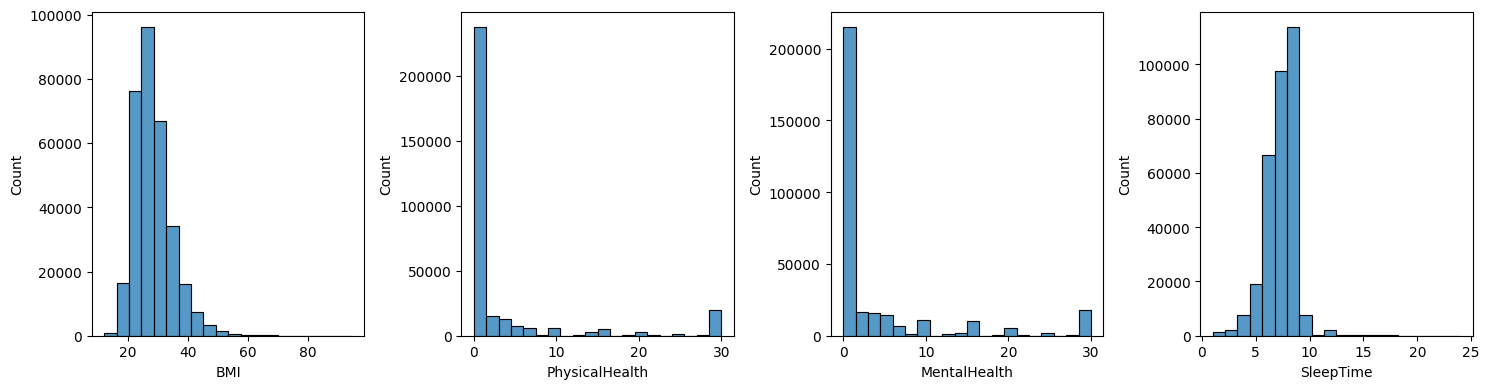

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for i, col in enumerate(['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']):
    sns.histplot(df_mtw[col], bins=20, ax=axes[i])

plt.tight_layout()
plt.show()

These variables can be considered as true numeric ones

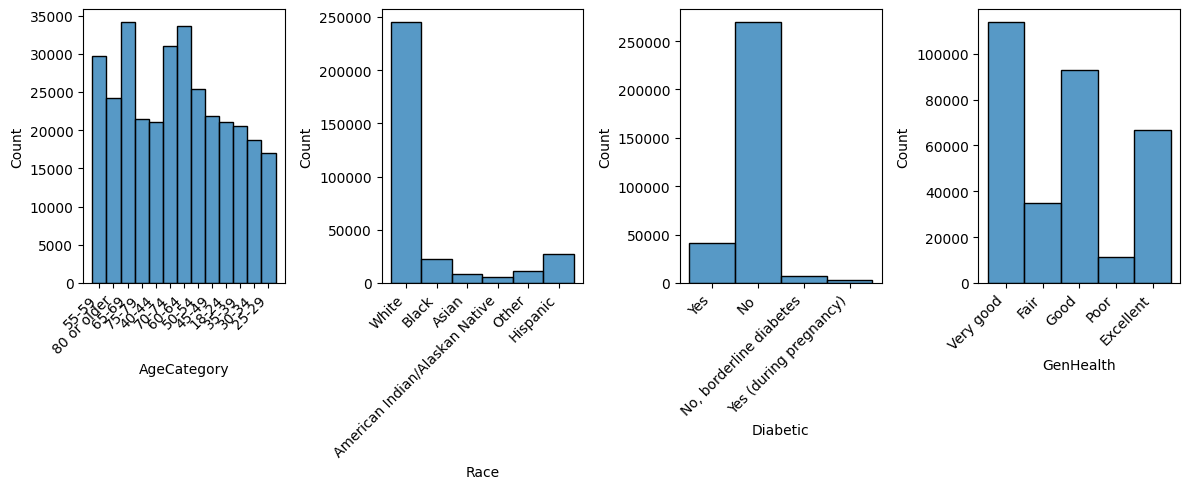

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(12, 5))

for i, col in enumerate(['AgeCategory', 'Race', 'Diabetic','GenHealth']):
    sns.histplot(df_mtw[col], bins=len(df_mtw[col].unique()), ax=axes[i])
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')


plt.tight_layout()
plt.show()

let's look at the correlations between float variables.

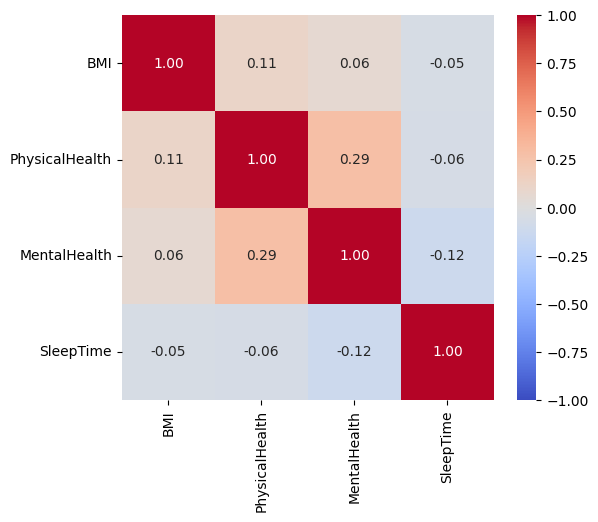

In [11]:
df_float = df.loc[:,df.dtypes == np.float64]
corr = df_float.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, vmin=-1, vmax=1)
plt.show()

As we can see, there are no pairs of highly correlated variables, so the linear models will not be unstable due to this

### Preparing data for training

In [12]:
y = 'HeartDisease'

df[y] = df[y].map({'Yes': 1, 'No': 0})

df_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

X_train = df_train.loc[:, df.columns != y].copy()
X_test = df_test.loc[:, df.columns != y].copy()

y_train = df_train[y].values
y_test = df_test[y].values

for d in [X_train, X_test]:
    print(round(len(d)/len(df),2))

0.8
0.2


In [13]:
dv = DictVectorizer(sparse=False)

train_dict = X_train.to_dict(orient='records')
X_train_1hot = dv.fit_transform(train_dict)

test_dict = X_test.to_dict(orient='records')
X_test_1hot = dv.transform(test_dict)

A simple analysis of feature importance for float64 features. We will use only the training set for this purpose

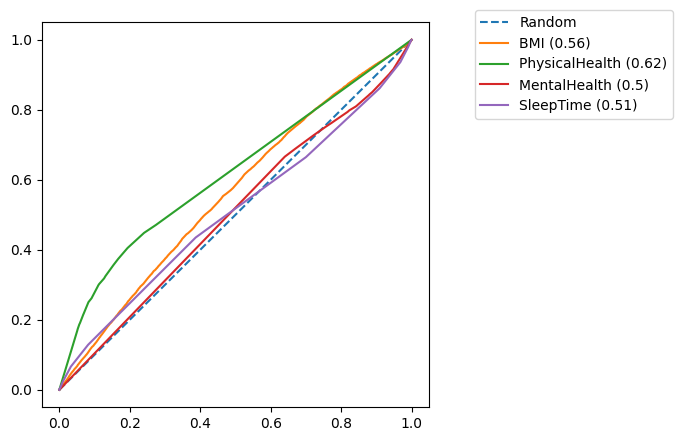

In [14]:
plt.figure(figsize=(5,5))
plt.plot([0,1], [0,1], label='Random', linestyle='--')

num_cols = X_train.columns[X_train.dtypes == np.float64]

auc_values = {}

for col in num_cols:
    fpr, tpr, thresholds = roc_curve(y_train, X_train[col])
    auc_value = auc(fpr, tpr)

    auc_values[col] = auc_value
    
    if auc_value < 0.5:
        fpr, tpr, thresholds = roc_curve(y_train, -X_train[col])
        auc_value = auc(fpr, tpr)
    label = f'{col} ({round(auc_value,2)})'
    plt.plot(fpr, tpr, label=label)

auc_values = {k: v for k, v in sorted(auc_values.items(), key=lambda item: item[1], reverse=True)}
plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.show()

### Training

#### Baseline model (logistic regression)

Let's train the baseline model and adjust a threshold for decision-making

AUC:	0.843
F1:	0.18
F1 thr:	0.401
Best threshold (F1-Score): 0.192


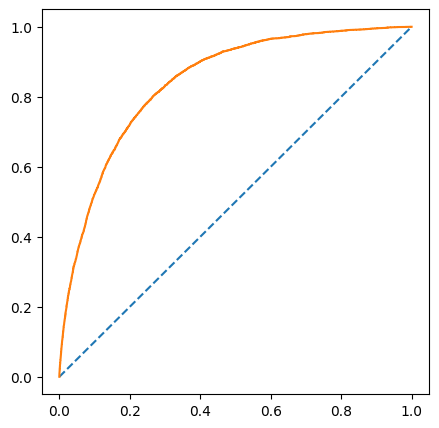

In [15]:
model_baseline = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=1)
model_baseline.fit(X_train_1hot, y_train)

y_pred = model_baseline.predict_proba(X_test_1hot)[:, 1]
y_pred_proba = model_baseline.predict_proba(X_test_1hot)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

auc_value = auc(fpr, tpr)
f1_value = f1_score(y_test, model_baseline.predict(X_test_1hot))
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10) # 1e-10 is here to avoid division by zero
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_thr = [1 if y > best_threshold else 0 for y in y_pred_proba]
f1_thr = f1_score(y_test, y_pred_thr)

print(f'AUC:\t{round(auc_value, 3)}')
print(f'F1:\t{round(f1_value, 3)}')
print(f'F1 thr:\t{round(f1_thr, 3)}')
print(f"Best threshold (F1-Score): {round(best_threshold, 3)}")


plt.figure(figsize=(5,5))
plt.plot([0,1], [0,1], label='Random', linestyle='--')
plt.plot(fpr, tpr)
plt.show()

#### Grid Search

In [16]:
model_hyperparams = {
        'LogisticRegression': {
            'model': LogisticRegression(solver='liblinear', max_iter=1000, random_state=1),
            'params': {
                'C': [0.01, 0.1, 1, 6, 7, 8, 9, 10, 11, 50],
                'penalty': ['l1', 'l2']
            }
        },
        'DecisionTreeClassifier': {
            'model': DecisionTreeClassifier(random_state=1),
            'params': {
                'max_depth': [7, 8, 9, 10, 11],
                'min_samples_split': [2,  5],
                'min_samples_leaf': [1, 4, 8]
            }
        },
        'RandomForestClassifier': {
            'model': RandomForestClassifier(random_state=1),
            'params': {
                'n_estimators': [5, 10, 15, 20],
                'max_depth': [7, 8, 9, 10, 11],
                'min_samples_split': [2, 5],
                'min_samples_leaf': [1, 4, 8]
            }
        }
}

best_models = {}

for model_name, mp in model_hyperparams.items():
    print(f"Running GridSearchCV for {model_name}...")
    grid_search = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1', n_jobs=4)
    
    grid_search.fit(X_train_1hot, y_train)
    
    best_models[model_name] = [grid_search.best_estimator_, grid_search.best_score_]
    
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best cross-validation score: {round(grid_search.best_score_, 3)}\n")

for model_name, model in best_models.items():
    print(f"\nEvaluating the best {model_name} on the validation set:")
    y_pred = model[0].predict(X_test_1hot)
    print(classification_report(y_test, y_pred))

the_best_model = best_models[max(best_models, key=lambda k: best_models[k][1])][0]

Running GridSearchCV for LogisticRegression...
Best parameters for LogisticRegression: {'C': 6, 'penalty': 'l2'}
Best cross-validation score: 0.179

Running GridSearchCV for DecisionTreeClassifier...
Best parameters for DecisionTreeClassifier: {'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score: 0.149

Running GridSearchCV for RandomForestClassifier...
Best parameters for RandomForestClassifier: {'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 5}
Best cross-validation score: 0.111


Evaluating the best LogisticRegression on the validation set:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     58574
           1       0.53      0.11      0.18      5385

    accuracy                           0.92     63959
   macro avg       0.73      0.55      0.57     63959
weighted avg       0.89      0.92      0.89     63959


Evaluating the best DecisionTreeClassifier on the

In [17]:
the_best_model

LogisticRegression(C=6, max_iter=1000, random_state=1, solver='liblinear')

In [18]:
y_pred = the_best_model.predict(X_test_1hot)
y_pred_proba = the_best_model.predict_proba(X_test_1hot)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

auc_value = auc(fpr, tpr)
f1_value = f1_score(y_test, y_pred)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10) # 1e-10 is here to avoid division by zero
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_thr = [1 if y > best_threshold else 0 for y in y_pred_proba]
f1_thr = f1_score(y_test, y_pred_thr)

print(f'AUC:\t{round(auc_value, 3)}')
print(f'F1:\t{round(f1_value, 3)}')
print(f'F1 thr:\t{round(f1_thr, 3)}')
print(f"Best threshold (F1-Score): {round(best_threshold, 3)}")

AUC:	0.843
F1:	0.181
F1 thr:	0.401
Best threshold (F1-Score): 0.193


In [19]:
# with open('../models/the_best_model.pkl', 'wb') as f_out: 
#     pickle.dump((dv, the_best_model), f_out)